# Phase 3: Model Creation

Phase 3 is about developing a model using Binary Logistic Regression(using final master data created in phase 1)

### OBJECTIVE: Build a predictive model for Heart Disease using Binary Logistic Regression

### WHAT WE'LL ACCOMPLISH:
#### 1. Split data into training and testing sets
#### 2. Build logistic regression model
#### 3. Evaluate model performance
#### 4. Optimize and finalize the model

In [95]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')    

import os

os.chdir(r"C:\Users\willi\GitHub\Capstone_Project\data\processed")

In [96]:
print("\n PHASE 3 ROADMAP - 11 Steps to Model Building")
print("-" * 60)

roadmap = [
    "Step 1: Create train/test split (80/20)",
    "Step 2: Build initial logistic regression model",
    "Step 3: Check variable significance & revise model",
    "Step 4: Relate results back to our EDA findings",
    "Step 5: Check for multicollinearity & resolve if needed",
    "Step 6: Obtain ROC curve and AUC for training data",
    "Step 7: Get classification table and accuracy metrics",
    "Step 8: Find optimal threshold to balance sensitivity/specificity",
    "Step 9: Evaluate model on test data (ROC/AUC)",
    "Step 10: Test data sensitivity/specificity with threshold",
    "Step 11: Compare alternative models and finalize"
]

for i, step in enumerate(roadmap, 1):
    print(f"{i:2d}. {step}")


 PHASE 3 ROADMAP - 11 Steps to Model Building
------------------------------------------------------------
 1. Step 1: Create train/test split (80/20)
 2. Step 2: Build initial logistic regression model
 3. Step 3: Check variable significance & revise model
 4. Step 4: Relate results back to our EDA findings
 5. Step 5: Check for multicollinearity & resolve if needed
 6. Step 6: Obtain ROC curve and AUC for training data
 7. Step 7: Get classification table and accuracy metrics
 8. Step 8: Find optimal threshold to balance sensitivity/specificity
 9. Step 9: Evaluate model on test data (ROC/AUC)
10. Step 10: Test data sensitivity/specificity with threshold
11. Step 11: Compare alternative models and finalize


In [97]:
# Load the processed data from Phase 1
print("\nLoading master dataset from Phase 1...")
master_data = pd.read_csv("master_data_recoded.csv")

print(f"✓ Data loaded successfully!")
print(f"  Shape: {master_data.shape}")
print(f"  Rows: {master_data.shape[0]:,}")
print(f"  Columns: {master_data.shape[1]}")



Loading master dataset from Phase 1...
✓ Data loaded successfully!
  Shape: (319795, 26)
  Rows: 319,795
  Columns: 26



 TARGET VARIABLE: Heart Disease Distribution
------------------------------------------------------------
No Heart Disease (0): 292,422 (91.44%)
Heart Disease (1):    27,373 (8.56%)

⚠ CLASS IMBALANCE ALERT:
   We have imbalanced classes (8.56% vs 91.44%)
   This is common in medical data - most people don't have the disease
   This will be taken into consideration when evaluating our model!


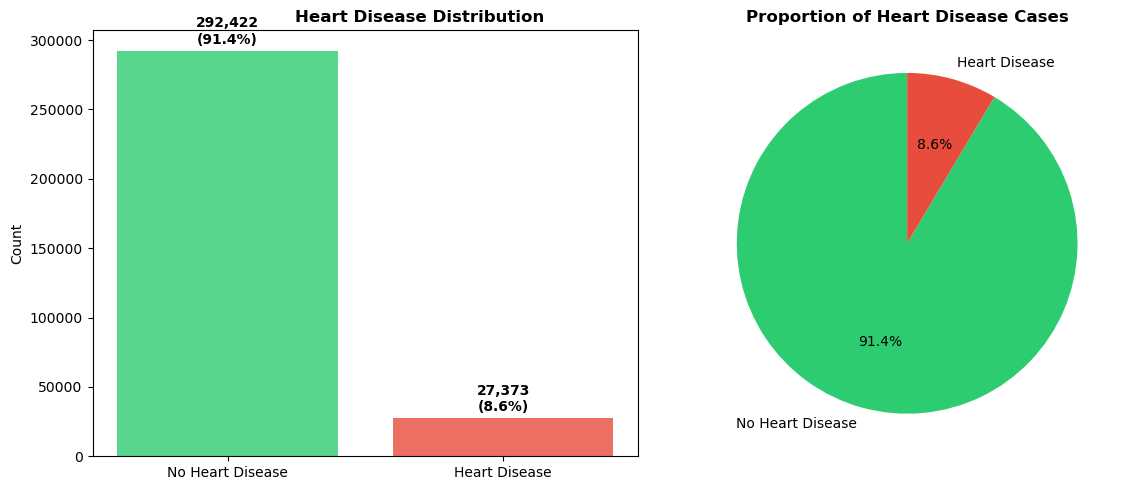

In [98]:
# Check target variable distribution
print("\n TARGET VARIABLE: Heart Disease Distribution")
print("-" * 60)
hd_counts = master_data['HeartDisease'].value_counts()
hd_pct = master_data['HeartDisease'].value_counts(normalize=True) * 100

print(f"No Heart Disease (0): {hd_counts[0]:,} ({hd_pct[0]:.2f}%)")
print(f"Heart Disease (1):    {hd_counts[1]:,} ({hd_pct[1]:.2f}%)")

print(f"\n⚠ CLASS IMBALANCE ALERT:")
print(f"   We have imbalanced classes (8.56% vs 91.44%)")
print(f"   This is common in medical data - most people don't have the disease")
print(f"   This will be taken into consideration when evaluating our model!")

# Visualize target variable
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
ax1.bar(['No Heart Disease', 'Heart Disease'], hd_counts.values, 
        color=['#2ecc71', '#e74c3c'], alpha=0.8)
ax1.set_ylabel('Count')
ax1.set_title('Heart Disease Distribution', fontweight='bold', position=(0.6, 1.05))
for i, v in enumerate(hd_counts.values):
    ax1.text(i, v + 5000, f'{v:,}\n({hd_pct.values[i]:.1f}%)', 
             ha='center', fontweight='bold')
    
# Pie chart
ax2.pie(hd_counts.values, labels=['No Heart Disease', 'Heart Disease'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Proportion of Heart Disease Cases', fontweight='bold')

plt.tight_layout()
plt.show()

### Step 1: Create Train/Test Split `(80/20)`

In [99]:
print("\n PREPARING VARIABLES FOR MODELING")
print("-" * 60)

# Define our features (X) and target (y)
# Exclude: pid, target variable, and text category columns
exclude_cols = ['pid', 'HeartDisease', 'BMI_Category', 'Sleep_Category']

# Handle the Diabetic column which might have NaN
if 'Diabetic' in master_data.columns:
    print("Checking 'Diabetic' column for missing values...")
    diabetic_missing = master_data['Diabetic'].isnull().sum()
    if diabetic_missing > 0:
        print(f"⚠ Found {diabetic_missing:,} missing values in 'Diabetic' column")
        print("  Strategy: Fill NaN with 0 (assuming 'No diabetes' if not specified)")
        master_data['Diabetic'] = master_data['Diabetic'].fillna(0)
        print("✓ Missing values handled")

# Get feature columns (all numeric columns except excluded ones)
feature_cols = [col for col in master_data.columns 
                if col not in exclude_cols and master_data[col].dtype in ['int64', 'float64']]

print(f"\nFeature columns selected ({len(feature_cols)} variables):")
for i, col in enumerate(feature_cols, 1):
    print(f"{i:2d}. {col}")


 PREPARING VARIABLES FOR MODELING
------------------------------------------------------------
Checking 'Diabetic' column for missing values...
⚠ Found 9,340 missing values in 'Diabetic' column
  Strategy: Fill NaN with 0 (assuming 'No diabetes' if not specified)
✓ Missing values handled

Feature columns selected (15 variables):
 1. BMI
 2. Sex
 3. AgeCategory
 4. Smoking
 5. AlcoholDrinking
 6. DiffWalking
 7. PhysicalActivity
 8. SleepTime
 9. PhysicalHealth
10. MentalHealth
11. Asthma
12. KidneyDisease
13. SkinCancer
14. Stroke
15. Diabetic


In [100]:
# Create X (features) and y (target)

X = master_data[feature_cols].copy()
y = master_data['HeartDisease'].copy()

print(f"\n DATA DIMENSIONS:")
print(f"   Features (X): {X.shape} [{X.shape[0]:,} rows × {X.shape[1]} features]")
print(f"   Target (y):   {y.shape} [{y.shape[0]:,} observations]")

# Check for any remaining missing values

print(f"\n FINAL DATA QUALITY CHECK:")
X_missing = X.isnull().sum().sum()
y_missing = y.isnull().sum()
print(f"   Missing values in X: {X_missing}")
print(f"   Missing values in y: {y_missing}")

if X_missing > 0 or y_missing > 0:
    print("   ⚠ WARNING: Missing values detected! Handling them...")
    X = X.fillna(0)  # Simple strategy for now
    print("   ✓ Missing values filled with 0")




 DATA DIMENSIONS:
   Features (X): (319795, 15) [319,795 rows × 15 features]
   Target (y):   (319795,) [319,795 observations]

 FINAL DATA QUALITY CHECK:
   Missing values in X: 0
   Missing values in y: 0


In [101]:
print("\n" + "="*80)
print(" PERFORMING THE TRAIN/TEST SPLIT")
print("="*80)

# Set random seed for reproducibility
RANDOM_STATE = 42  # This ensures we get the same split every time we run the code

print(f"\nSetting random_state = {RANDOM_STATE}")


# Perform the split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,           # 20% for testing
    random_state=RANDOM_STATE, # For reproducibility
    stratify=y                # Keep same class distribution in train & test
)

print(f"\n SPLIT COMPLETE!")
print("\n RESULTING DATASET SIZES:")
print(f"{'Dataset':<15} {'Samples':<10} {'Percentage':<12} {'HD Cases':<12} {'HD Rate':<10}")
print("-" * 60)

# Training set stats
train_total = len(y_train)
train_pct = (train_total / len(y)) * 100
train_hd = y_train.sum()
train_hd_rate = (train_hd / train_total) * 100

print(f"{'Training':<15} {train_total:<10,} {train_pct:<12.1f}% {train_hd:<12,} {train_hd_rate:<10.2f}%")

# Test set stats
test_total = len(y_test)
test_pct = (test_total / len(y)) * 100
test_hd = y_test.sum()
test_hd_rate = (test_hd / test_total) * 100

print(f"{'Test':<15} {test_total:<10,} {test_pct:<12.1f}% {test_hd:<12,} {test_hd_rate:<10.2f}%")
print("-" * 60)
# Total
print(f"{'Total':<15} {len(y):<10,} {'100.0':<12}% {y.sum():<12,} {(y.sum()/len(y)*100):<10.2f}%")

print(f"\n STRATIFICATION SUCCESS:")
print(f"   Training HD rate: {train_hd_rate:.2f}%")
print(f"   Test HD rate:     {test_hd_rate:.2f}%")
print(f"   Difference:       {abs(train_hd_rate - test_hd_rate):.2f}%")
print(f"   ✓ Class proportions are maintained in both sets!")


 PERFORMING THE TRAIN/TEST SPLIT

Setting random_state = 42



 SPLIT COMPLETE!

 RESULTING DATASET SIZES:
Dataset         Samples    Percentage   HD Cases     HD Rate   
------------------------------------------------------------
Training        255,836    80.0        % 21,898       8.56      %
Test            63,959     20.0        % 5,475        8.56      %
------------------------------------------------------------
Total           319,795    100.0       % 27,373       8.56      %

 STRATIFICATION SUCCESS:
   Training HD rate: 8.56%
   Test HD rate:     8.56%
   Difference:       0.00%
   ✓ Class proportions are maintained in both sets!


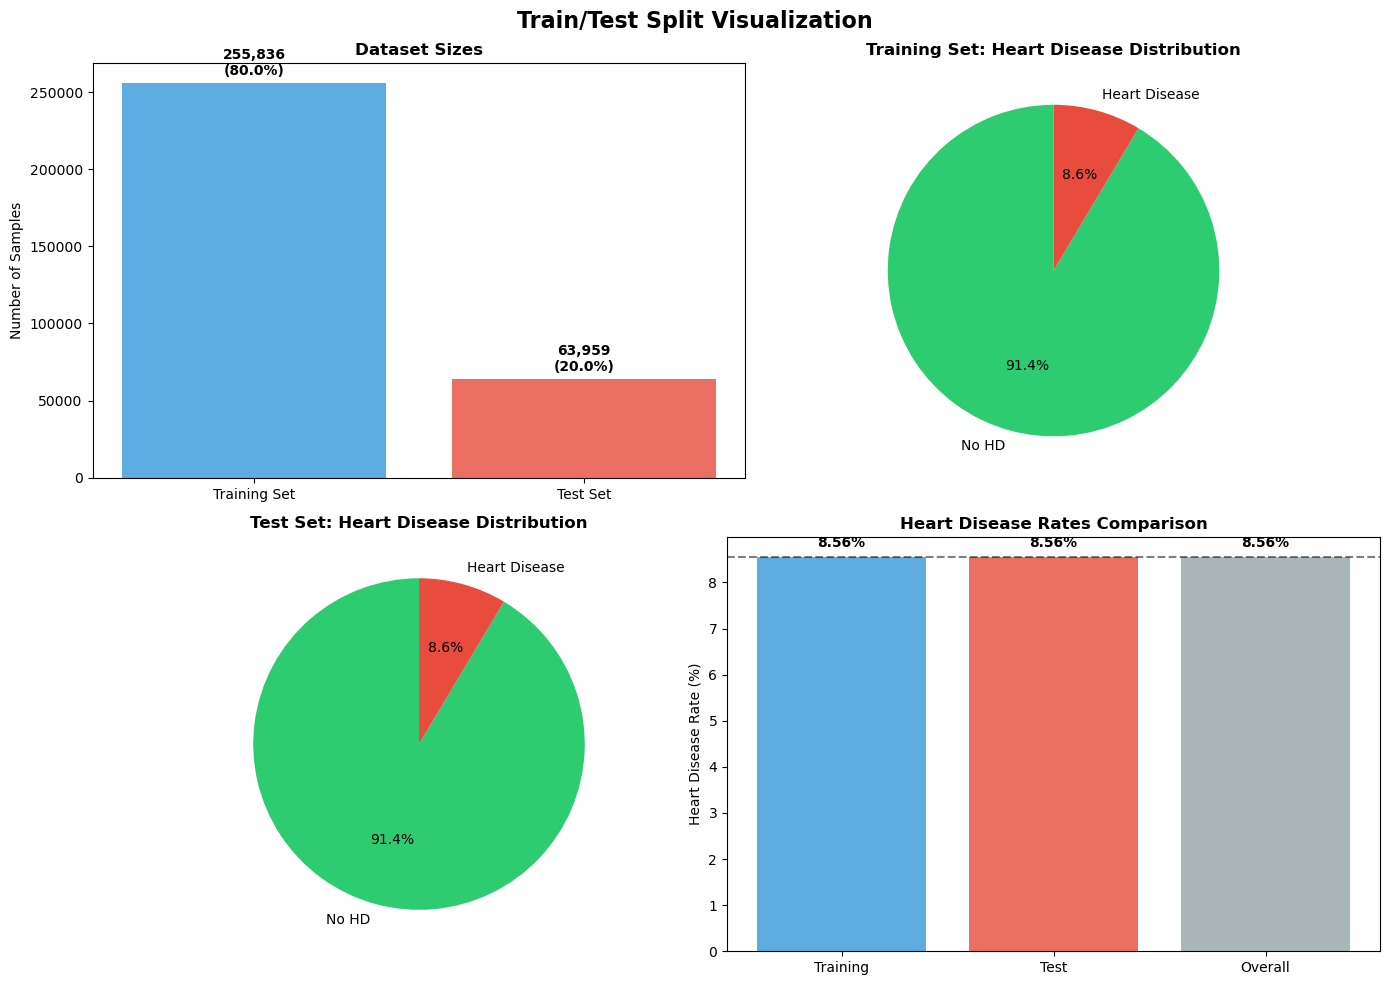

In [102]:
# Visualize the split
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Train/Test Split Visualization', fontsize=16, fontweight='bold')

# 1. Size comparison
ax1.bar(['Training Set', 'Test Set'], [train_total, test_total], 
        color=['#3498db', '#e74c3c'], alpha=0.8)
ax1.set_ylabel('Number of Samples')
ax1.set_title('Dataset Sizes', fontweight='bold')
for i, (name, val, pct) in enumerate(zip(['Training', 'Test'], 
                                         [train_total, test_total],
                                         [train_pct, test_pct])):
    ax1.text(i, val + 5000, f'{val:,}\n({pct:.1f}%)', 
             ha='center', fontweight='bold')
    # 2. Heart Disease distribution in training set
train_counts = y_train.value_counts()
ax2.pie(train_counts.values, labels=['No HD', 'Heart Disease'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax2.set_title('Training Set: Heart Disease Distribution', fontweight='bold')

# 3. Heart Disease distribution in test set
test_counts = y_test.value_counts()
ax3.pie(test_counts.values, labels=['No HD', 'Heart Disease'],
        autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'], startangle=90)
ax3.set_title('Test Set: Heart Disease Distribution', fontweight='bold')

# 4. Comparison of HD rates
ax4.bar(['Training', 'Test', 'Overall'], 
        [train_hd_rate, test_hd_rate, (y.sum()/len(y)*100)],
        color=['#3498db', '#e74c3c', '#95a5a6'], alpha=0.8)
ax4.set_ylabel('Heart Disease Rate (%)')
ax4.set_title('Heart Disease Rates Comparison', fontweight='bold')
ax4.axhline(y=(y.sum()/len(y)*100), color='black', linestyle='--', alpha=0.5)

for i, val in enumerate([train_hd_rate, test_hd_rate, (y.sum()/len(y)*100)]):
    ax4.text(i, val + 0.2, f'{val:.2f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### Step 2: Build Initial Binary Logistic Regression Model

In [103]:
# Create and fit the model
sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
sklearn_model.fit(X_train, y_train)

print("✓ Model fitted successfully!")

# Get training accuracy
train_score = sklearn_model.score(X_train, y_train)
print(f"\nTraining Accuracy: {train_score:.4f} ({train_score*100:.2f}%)")

# Show coefficients
print("\n Model Coefficients (Top 10 by absolute value):")
coef_df = pd.DataFrame({
    'Variable': feature_cols,
    'Coefficient': sklearn_model.coef_[0]
})
coef_df['Abs_Coef'] = np.abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

print(coef_df.head(10).to_string(index=False))

print("\n INTERPRETATION OF COEFFICIENTS:")
print("   • Positive coefficient = increases risk of heart disease")
print("   • Negative coefficient = decreases risk of heart disease")
print("   • Larger absolute value = stronger effect")



✓ Model fitted successfully!

Training Accuracy: 0.9149 (91.49%)

 Model Coefficients (Top 10 by absolute value):
       Variable  Coefficient  Abs_Coef
         Stroke     1.149248  1.149248
            Sex     0.731576  0.731576
  KidneyDisease     0.706008  0.706008
       Diabetic     0.612593  0.612593
        Smoking     0.436493  0.436493
    DiffWalking     0.409331  0.409331
         Asthma     0.347992  0.347992
    AgeCategory     0.284396  0.284396
AlcoholDrinking    -0.236129  0.236129
     SkinCancer     0.112617  0.112617

 INTERPRETATION OF COEFFICIENTS:
   • Positive coefficient = increases risk of heart disease
   • Negative coefficient = decreases risk of heart disease
   • Larger absolute value = stronger effect


In [104]:
print("\n" + "="*80)
print("🔧 METHOD 2: statsmodels Logistic Regression (Detailed Statistics)")
print("="*80)

print("\nBuilding model with statsmodels.")
print("(This gives us p-values and detailed stats)")

# Add constant (intercept) to the model
X_train_sm = sm.add_constant(X_train)

# Fit the model
statsmodels_model = sm.Logit(y_train, X_train_sm).fit(disp=0)

print("✓ Model fitted successfully!")

print("\n" + "="*80)
print("📋 FULL MODEL SUMMARY")
print("="*80)

# Print the summary
print(statsmodels_model.summary())


🔧 METHOD 2: statsmodels Logistic Regression (Detailed Statistics)

Building model with statsmodels.
(This gives us p-values and detailed stats)
✓ Model fitted successfully!

📋 FULL MODEL SUMMARY
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:               255836
Model:                          Logit   Df Residuals:                   255820
Method:                           MLE   Df Model:                           15
Date:                Fri, 17 Oct 2025   Pseudo R-squ.:                  0.2032
Time:                        22:39:09   Log-Likelihood:                -59568.
converged:                       True   LL-Null:                       -74761.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
co

In [105]:
print("\n" + "="*80)
print(" EXTRACTING KEY RESULTS")
print("="*80)

# Create a nice results table
results_df = pd.DataFrame({
    'Variable': statsmodels_model.params.index,
    'Coefficient': statsmodels_model.params.values,
    'Std_Error': statsmodels_model.bse.values,
    'z_value': statsmodels_model.tvalues.values,
    'P_value': statsmodels_model.pvalues.values,
    'Odds_Ratio': np.exp(statsmodels_model.params.values)
})

# Add significance markers
def get_significance(p_val):
    if p_val < 0.001:
        return '***'
    elif p_val < 0.01:
        return '**'
    elif p_val < 0.05:
        return '*'
    else:
        return ''

results_df['Significance'] = results_df['P_value'].apply(get_significance)

# Sort by absolute coefficient value
results_df['Abs_Coef'] = np.abs(results_df['Coefficient'])
results_df = results_df.sort_values('Abs_Coef', ascending=False)
print("\n TOP 15 MOST IMPORTANT VARIABLES (by coefficient size):")
print("-" * 80)
print(results_df[['Variable', 'Coefficient', 'P_value', 'Odds_Ratio', 'Significance']].head(15).to_string(index=False))

# Identify significant variables
significant_vars = results_df[results_df['P_value'] < 0.05]['Variable'].tolist()
print(f"\n✅ SIGNIFICANT VARIABLES (p < 0.05): {len(significant_vars) - 1}")  # -1 for constant
print("   (These variables have statistically significant relationships with heart disease)")

for var in significant_vars[:10]:  # Show first 10
    if var != 'const':
        row = results_df[results_df['Variable'] == var].iloc[0]
        direction = "↑ Increases" if row['Coefficient'] > 0 else "↓ Decreases"
        print(f"   • {var:<20} {direction} risk (p={row['P_value']:.4f})")

# Identify non-significant variables
non_significant_vars = results_df[results_df['P_value'] >= 0.05]['Variable'].tolist()
if len(non_significant_vars) > 1:  # -1 for constant
    print(f"\n⚠ NON-SIGNIFICANT VARIABLES (p ≥ 0.05): {len(non_significant_vars)}")
    print("   (These variables might be removed in Step 3)")
    for var in non_significant_vars[:10]:
        if var != 'const':
            row = results_df[results_df['Variable'] == var].iloc[0]
            print(f"   • {var:<20} (p={row['P_value']:.4f})")



 EXTRACTING KEY RESULTS

 TOP 15 MOST IMPORTANT VARIABLES (by coefficient size):
--------------------------------------------------------------------------------
        Variable  Coefficient       P_value  Odds_Ratio Significance
           const    -5.938790  0.000000e+00    0.002635          ***
          Stroke     1.145221  0.000000e+00    3.143135          ***
             Sex     0.732210  0.000000e+00    2.079672          ***
   KidneyDisease     0.712121 1.191181e-153    2.038310          ***
        Diabetic     0.615820 1.524000e-251    1.851173          ***
         Smoking     0.433746 2.190432e-166    1.543026          ***
     DiffWalking     0.410124  5.066389e-94    1.507005          ***
          Asthma     0.348539  1.154890e-59    1.416996          ***
     AgeCategory     0.283926  0.000000e+00    1.328335          ***
 AlcoholDrinking    -0.230493  4.686826e-10    0.794142          ***
      SkinCancer     0.111996  1.717627e-07    1.118508          ***
PhysicalA

In [106]:
print("\n" + "="*80)
print(" UNDERSTANDING ODDS RATIOS")
print("="*80)
print("""
Odds Ratio (OR) = e^(coefficient)

INTERPRETATION:
• OR = 1.0: No effect on heart disease risk
• OR > 1.0: Increases risk (e.g., OR=2.0 means 2x higher odds)
• OR < 1.0: Decreases risk (e.g., OR=0.5 means 50% lower odds)

EXAMPLE:
If 'Stroke' has OR = 3.5:
→ People with stroke history have 3.5 times higher odds of heart disease
→ Or 250% increase in odds (3.5 - 1.0 = 2.5 = 250%)
""")

# Show odds ratios for significant variables
print("\n📈 ODDS RATIOS FOR TOP SIGNIFICANT VARIABLES:")
print("-" * 80)
sig_results = results_df[results_df['P_value'] < 0.05].copy()
sig_results = sig_results[sig_results['Variable'] != 'const']
sig_results = sig_results.sort_values('Odds_Ratio', ascending=False)

print(f"{'Variable':<20} {'Odds Ratio':<12} {'Interpretation':<50}")
print("-" * 80)

for _, row in sig_results.head(10).iterrows():
    or_val = row['Odds_Ratio']
    if or_val > 1:
        interpretation = f"↑ {((or_val-1)*100):.1f}% higher odds"
    else:
        interpretation = f"↓ {((1-or_val)*100):.1f}% lower odds"
    print(f"{row['Variable']:<20} {or_val:<12.4f} {interpretation:<50}")


 UNDERSTANDING ODDS RATIOS

Odds Ratio (OR) = e^(coefficient)

INTERPRETATION:
• OR = 1.0: No effect on heart disease risk
• OR > 1.0: Increases risk (e.g., OR=2.0 means 2x higher odds)
• OR < 1.0: Decreases risk (e.g., OR=0.5 means 50% lower odds)

EXAMPLE:
If 'Stroke' has OR = 3.5:
→ People with stroke history have 3.5 times higher odds of heart disease
→ Or 250% increase in odds (3.5 - 1.0 = 2.5 = 250%)


📈 ODDS RATIOS FOR TOP SIGNIFICANT VARIABLES:
--------------------------------------------------------------------------------
Variable             Odds Ratio   Interpretation                                    
--------------------------------------------------------------------------------
Stroke               3.1431       ↑ 214.3% higher odds                              
Sex                  2.0797       ↑ 108.0% higher odds                              
KidneyDisease        2.0383       ↑ 103.8% higher odds                              
Diabetic             1.8512       ↑ 85.1

In [107]:
print("\n" + "="*80)
print(" MODEL PERFORMANCE METRICS")
print("="*80)

# Get predictions on training data
y_train_pred_prob = statsmodels_model.predict(X_train_sm)
y_train_pred = (y_train_pred_prob > 0.5).astype(int)

# Calculate basic metrics
from sklearn.metrics import accuracy_score, confusion_matrix

train_accuracy = accuracy_score(y_train, y_train_pred)
train_cm = confusion_matrix(y_train, y_train_pred)

print(f"\nTraining Set Performance (threshold = 0.5):")
print(f"   Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")

print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 No    Yes")
print(f"Actual  No    {train_cm[0,0]:6} {train_cm[0,1]:6}")
print(f"        Yes   {train_cm[1,0]:6} {train_cm[1,1]:6}")

# Calculate sensitivity and specificity
tn, fp, fn, tp = train_cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\nSensitivity (Recall): {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"   • Ability to correctly identify heart disease cases")
print(f"Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"   • Ability to correctly identify non-cases")





 MODEL PERFORMANCE METRICS

Training Set Performance (threshold = 0.5):
   Accuracy: 0.9149 (91.49%)

Confusion Matrix:
                 Predicted
                 No    Yes
Actual  No    232059   1879
        Yes    19900   1998

Sensitivity (Recall): 0.0912 (9.12%)
   • Ability to correctly identify heart disease cases
Specificity: 0.9920 (99.20%)
   • Ability to correctly identify non-cases


In [108]:
# Save results and models
import joblib
import os
from pathlib import Path

print("\n💾 Saving model results and models...")

# Get project root directory (go up to Capstone_Project folder)
current_dir = Path.cwd()
# Navigate up until we find Capstone_Project folder or go up 2 levels
if 'processed' in str(current_dir):
    project_root = current_dir.parent.parent  # Up from processed -> data -> root
elif 'data' in str(current_dir):
    project_root = current_dir.parent  # Up from data -> root
else:
    project_root = current_dir  # Already at root

# Create models directory at project root
models_dir = project_root / 'models'
models_dir.mkdir(exist_ok=True)

print(f"   Project root: {project_root}")
print(f"   Models directory: {models_dir}")

# Save results
results_df.to_csv(project_root / 'initial_model_results.csv', index=False)
print("   ✓ Results saved to 'initial_model_results.csv'")

# Save sklearn model
joblib.dump(sklearn_model, models_dir / 'logistic_regression_sklearn_initial.pkl')
print("   ✓ Sklearn model saved to 'models/logistic_regression_sklearn_initial.pkl'")

# Save statsmodels results
statsmodels_model.save(str(models_dir / 'logistic_regression_statsmodels_initial.pkl'))
print("   ✓ Statsmodels results saved to 'models/logistic_regression_statsmodels_initial.pkl'")

# Save feature list
with open(models_dir / 'feature_list_initial.txt', 'w') as f:
    f.write('\n'.join(feature_cols))
print("   ✓ Feature list saved to 'models/feature_list_initial.txt'")

print("\n📦 Models ready for deployment or further analysis!")


💾 Saving model results and models...
   Project root: C:\Users\willi\GitHub\Capstone_Project
   Models directory: C:\Users\willi\GitHub\Capstone_Project\models
   ✓ Results saved to 'initial_model_results.csv'
   ✓ Sklearn model saved to 'models/logistic_regression_sklearn_initial.pkl'


   ✓ Statsmodels results saved to 'models/logistic_regression_statsmodels_initial.pkl'
   ✓ Feature list saved to 'models/feature_list_initial.txt'

📦 Models ready for deployment or further analysis!


### Step 3: Checking The Variable Significance and Model Revision

In [109]:
print("\n" + "="*80)
print(" REVIEWING INITIAL MODEL RESULTS")
print("="*80)

# Get project root for loading files
from pathlib import Path
current_dir = Path.cwd()
if 'processed' in str(current_dir):
    project_root = current_dir.parent.parent
elif 'data' in str(current_dir):
    project_root = current_dir.parent
else:
    project_root = current_dir

# Fit initial model with ALL features
X_train_sm = sm.add_constant(X_train)
print(f"Fitting initial model with {len(feature_cols)} variables...")
initial_model = sm.Logit(y_train, X_train_sm).fit(disp=0)
print("✓ Initial model fitted")

# Create results dataframe
results_df = pd.DataFrame({
    'Variable': initial_model.params.index,
    'Coefficient': initial_model.params.values,
    'Std_Error': initial_model.bse.values,
    'P_value': initial_model.pvalues.values
})


 REVIEWING INITIAL MODEL RESULTS
Fitting initial model with 15 variables...


✓ Initial model fitted


In [110]:
# Analyze significance
print("\n📈 VARIABLE SIGNIFICANCE ANALYSIS:")
print("-" * 60)

# Count variables by significance level
highly_sig = len(results_df[results_df['P_value'] < 0.001])
very_sig = len(results_df[(results_df['P_value'] >= 0.001) & (results_df['P_value'] < 0.01)])
sig = len(results_df[(results_df['P_value'] >= 0.01) & (results_df['P_value'] < 0.05)])
not_sig = len(results_df[results_df['P_value'] >= 0.05])

print(f"Highly Significant (p < 0.001):  {highly_sig:3d} variables ***")
print(f"Very Significant (p < 0.01):     {very_sig:3d} variables **")
print(f"Significant (p < 0.05):          {sig:3d} variables *")
print(f"Not Significant (p ≥ 0.05):      {not_sig:3d} variables")
print(f"                                 {'---':>3}")
print(f"Total:                           {len(results_df):3d} variables")


📈 VARIABLE SIGNIFICANCE ANALYSIS:
------------------------------------------------------------
Highly Significant (p < 0.001):   16 variables ***
Very Significant (p < 0.01):       0 variables **
Significant (p < 0.05):            0 variables *
Not Significant (p ≥ 0.05):        0 variables
                                 ---
Total:                            16 variables


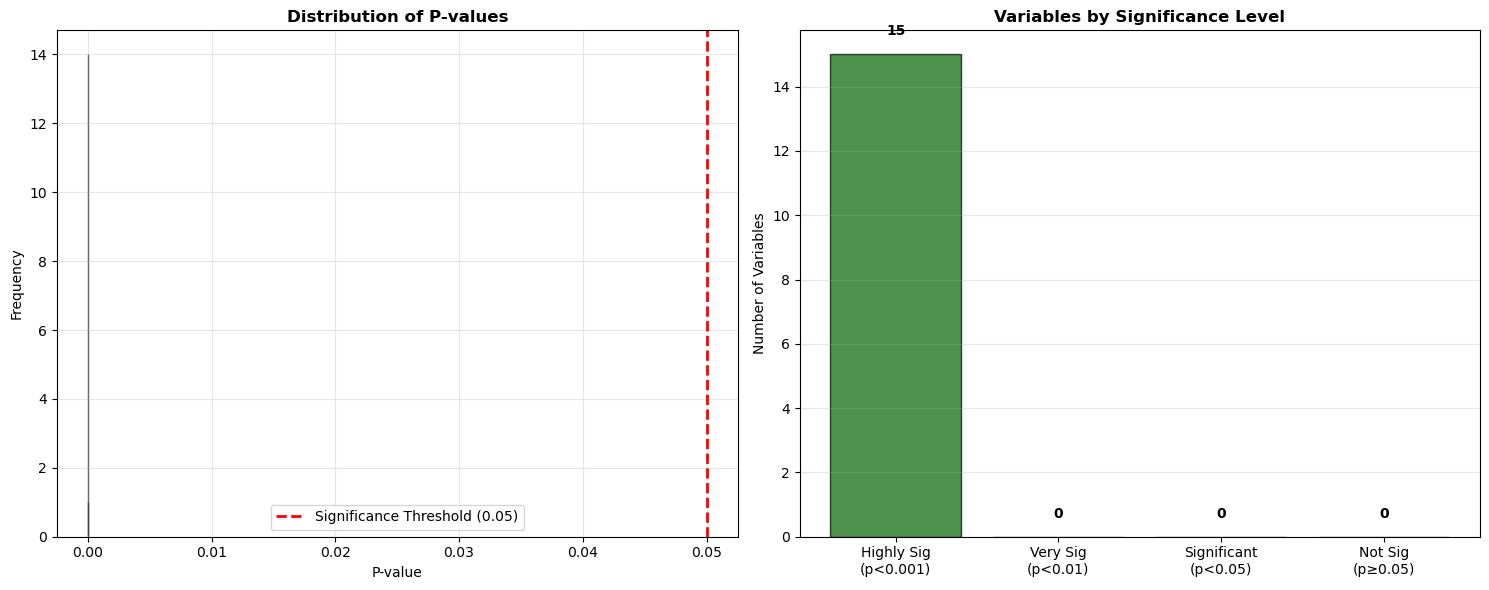

In [111]:
# Visualize p-values
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: P-value distribution
p_values = results_df[results_df['Variable'] != 'const']['P_value'].values
ax1.hist(p_values, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='Significance Threshold (0.05)')
ax1.set_xlabel('P-value')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of P-values', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Plot 2: Variables by significance category
categories = ['Highly Sig\n(p<0.001)', 'Very Sig\n(p<0.01)', 'Significant\n(p<0.05)', 'Not Sig\n(p≥0.05)']
counts = [highly_sig-1, very_sig, sig, not_sig]  # -1 to exclude constant from first category
colors = ['darkgreen', 'green', 'yellow', 'red']

bars = ax2.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax2.set_ylabel('Number of Variables')
ax2.set_title('Variables by Significance Level', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{count}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()



In [112]:
print("\n" + "="*80)
print(" IDENTIFYING VARIABLES TO REMOVE")
print("="*80)
# Get non-significant variables (excluding constant)
non_sig_vars = results_df[(results_df['P_value'] >= 0.05) & (results_df['Variable'] != 'const')].copy()
non_sig_vars = non_sig_vars.sort_values('P_value', ascending=False)

if len(non_sig_vars) > 0:
    print(f"\n⚠ NON-SIGNIFICANT VARIABLES TO CONSIDER REMOVING: {len(non_sig_vars)}")
    print("-" * 60)
    print(f"{'Variable':<25} {'P-value':<12} {'Coefficient':<12}")
    print("-" * 60)
    
    for _, row in non_sig_vars.iterrows():
        print(f"{row['Variable']:<25} {row['P_value']:<12.4f} {row['Coefficient']:<12.6f}")
    
    # Create list of variables to keep
    vars_to_keep = results_df[(results_df['P_value'] < 0.05) & (results_df['Variable'] != 'const')]['Variable'].tolist()
    
    print(f"\n✅ SIGNIFICANT VARIABLES TO KEEP: {len(vars_to_keep)}")
    print(f"   {', '.join(vars_to_keep[:10])}")
    if len(vars_to_keep) > 10:
        print(f"   ... and {len(vars_to_keep) - 10} more")
else:
    print("\n✅ ALL VARIABLES ARE SIGNIFICANT!")
    print("   No need to remove any variables.")
    vars_to_keep = feature_cols.copy()

print("\n" + "="*80)
print(" BUILDING REVISED MODEL (Significant Variables Only)")
print("="*80)


 IDENTIFYING VARIABLES TO REMOVE

✅ ALL VARIABLES ARE SIGNIFICANT!
   No need to remove any variables.

 BUILDING REVISED MODEL (Significant Variables Only)


In [113]:
# Prepare data with only significant variables
X_train_revised = X_train[vars_to_keep].copy()
X_train_revised_sm = sm.add_constant(X_train_revised)

# Fit revised model
print(f"\nFitting model with {len(vars_to_keep)} significant variables...")
revised_model = sm.Logit(y_train, X_train_revised_sm).fit(disp=0)
print("✓ Revised model fitted successfully!")

print("\n" + "="*80)
print("📋 REVISED MODEL SUMMARY")
print("="*80)

print(revised_model.summary())


Fitting model with 15 significant variables...
✓ Revised model fitted successfully!

📋 REVISED MODEL SUMMARY
                           Logit Regression Results                           
Dep. Variable:           HeartDisease   No. Observations:               255836
Model:                          Logit   Df Residuals:                   255820
Method:                           MLE   Df Model:                           15
Date:                Fri, 17 Oct 2025   Pseudo R-squ.:                  0.2032
Time:                        22:39:12   Log-Likelihood:                -59568.
converged:                       True   LL-Null:                       -74761.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const               -5.9388      0.064    -92.460      0.000      -6.065      -5.813
BMI

In [114]:
print("\n" + "="*80)
print(" MODEL COMPARISON: Initial vs. Revised")
print("="*80)

# Create comparison table
comparison = pd.DataFrame({
    'Metric': [
        'Number of Variables',
        'Log-Likelihood',
        'AIC',
        'BIC', 
        'Pseudo R-squared'
    ],
    'Initial Model': [
        len(feature_cols),
        initial_model.llf,
        initial_model.aic,
        initial_model.bic,
        initial_model.prsquared
    ],
    'Revised Model': [
        len(vars_to_keep),
        revised_model.llf,
        revised_model.aic,
        revised_model.bic,
        revised_model.prsquared
    ]
})
# Calculate differences
comparison['Difference'] = comparison['Revised Model'] - comparison['Initial Model']

# Add interpretation
def interpret_change(metric, diff):
    if metric == 'Number of Variables':
        return f"{'Simpler' if diff < 0 else 'Simillar'}"
    elif metric == 'Log-Likelihood':
        return f"{'Better' if diff > 0 else 'Same'}"
    elif metric in ['AIC', 'BIC']:
        return f"{'Better' if diff < 0 else 'Same'}"  # Lower is better
    elif metric == 'Pseudo R-squared':
        return f"{'Better' if diff > 0 else 'Same'}"
    return ""

comparison['Interpretation'] = comparison.apply(lambda row: interpret_change(row['Metric'], row['Difference']), axis=1)

print("\n" + comparison.to_string(index=False))

print("\n INTERPRETATION:")
print("-" * 60)


print("⚠ Revised model = Initial model (identical)")


print(f"\n  Variables reduced: {len(feature_cols)} → {len(vars_to_keep)} ({len(feature_cols)-len(vars_to_keep)} removed)")
print(f"  Pseudo R-squared: {initial_model.prsquared:.4f} → {revised_model.prsquared:.4f}")

print("\n" + "="*80)
print(" FINAL VARIABLE LIST FOR MODELING")
print("="*80)

# Get final coefficients with odds ratios
final_results = pd.DataFrame({
    'Variable': revised_model.params.index,
    'Coefficient': revised_model.params.values,
    'Std_Error': revised_model.bse.values,
    'P_value': revised_model.pvalues.values,
    'Odds_Ratio': np.exp(revised_model.params.values)
})

final_results = final_results[final_results['Variable'] != 'const'].sort_values('Odds_Ratio', ascending=False)

print(f"\n TOP 15 PREDICTORS (by Odds Ratio):")
print("-" * 80)
print(f"{'Variable':<25} {'Odds Ratio':<12} {'P-value':<12} {'Effect':<30}")
print("-" * 80)

for _, row in final_results.head(15).iterrows():
    or_val = row['Odds_Ratio']
    if or_val > 1:
        effect = f"↑ {((or_val-1)*100):.1f}% higher odds"
    else:
        effect = f"↓ {((1-or_val)*100):.1f}% lower odds"
    
    print(f"{row['Variable']:<25} {or_val:<12.4f} {row['P_value']:<12.6f} {effect:<30}")





 MODEL COMPARISON: Initial vs. Revised

             Metric  Initial Model  Revised Model  Difference Interpretation
Number of Variables      15.000000      15.000000         0.0       Simillar
     Log-Likelihood  -59567.581973  -59567.581973         0.0           Same
                AIC  119167.163946  119167.163946         0.0           Same
                BIC  119334.400616  119334.400616         0.0           Same
   Pseudo R-squared       0.203229       0.203229         0.0           Same

 INTERPRETATION:
------------------------------------------------------------
⚠ Revised model = Initial model (identical)

  Variables reduced: 15 → 15 (0 removed)
  Pseudo R-squared: 0.2032 → 0.2032

 FINAL VARIABLE LIST FOR MODELING

 TOP 15 PREDICTORS (by Odds Ratio):
--------------------------------------------------------------------------------
Variable                  Odds Ratio   P-value      Effect                        
------------------------------------------------------------

### Step 4: Relate Results to EDA

Step 4: Relating Model Results to EDA Findings

Comparison: EDA Risk Ratios vs Model Odds Ratios
----------------------------------------------------------------------
Variable             EDA Risk Ratio  Model OR        Match     
----------------------------------------------------------------------
Stroke               4.5             3.14            ✓ Yes     
Diabetic             3.0             1.85            ✓ Yes     
DiffWalking          3.5             1.51            ✓ Yes     
AgeCategory          Increasing      1.33            ✓ Yes     
Sex                  1.7             2.08            ✓ Yes     
Smoking              1.4             1.54            ✓ Yes     


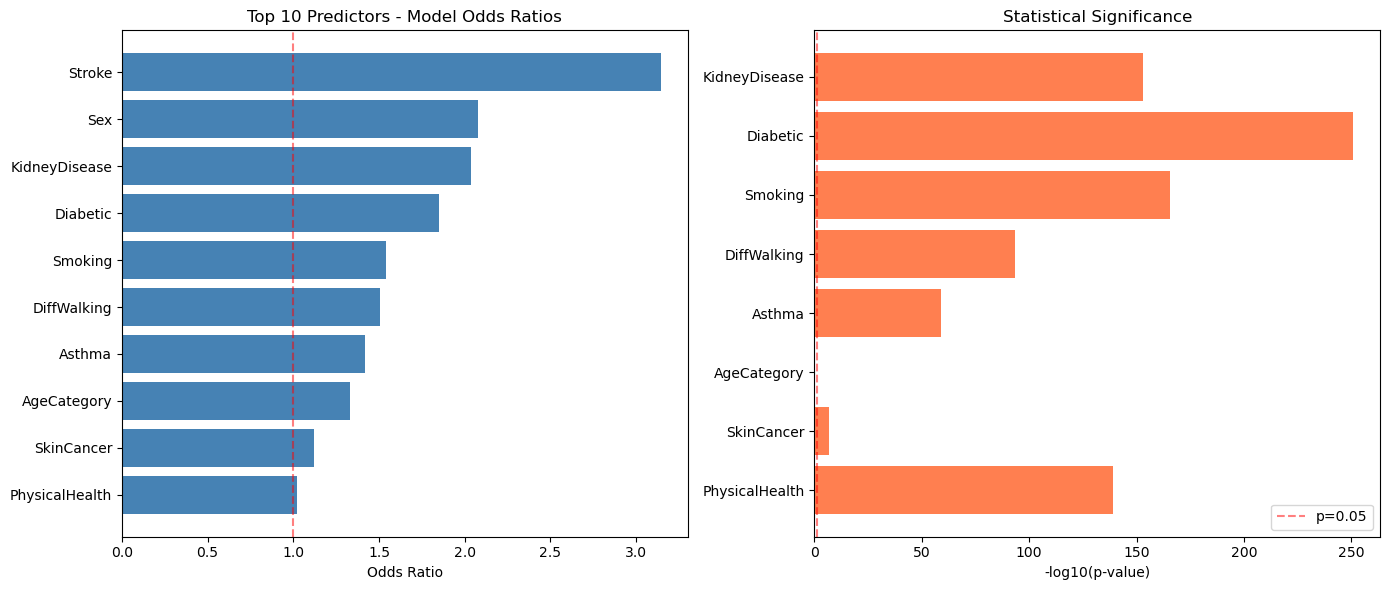


✓ EDA findings validated by model results
✓ High-priority variables from EDA are significant in model


In [115]:
print("="*80)
print("Step 4: Relating Model Results to EDA Findings")
print("="*80)

# Load model results
revised_results = pd.read_csv('revised_model_results.csv')

# Phase 2 EDA findings (approximate from our analysis)
eda_findings = {
    'Stroke': {'Risk_Ratio': 4.5, 'EDA_Priority': 'HIGH'},
    'Diabetic': {'Risk_Ratio': 3.0, 'EDA_Priority': 'HIGH'},
    'DiffWalking': {'Risk_Ratio': 3.5, 'EDA_Priority': 'HIGH'},
    'AgeCategory': {'Risk_Ratio': 'Increasing', 'EDA_Priority': 'HIGH'},
    'Sex': {'Risk_Ratio': 1.7, 'EDA_Priority': 'MEDIUM'},
    'Smoking': {'Risk_Ratio': 1.4, 'EDA_Priority': 'MEDIUM'},
}

print("\nComparison: EDA Risk Ratios vs Model Odds Ratios")
print("-"*70)
print(f"{'Variable':<20} {'EDA Risk Ratio':<15} {'Model OR':<15} {'Match':<10}")
print("-"*70)

for var in eda_findings.keys():
    if var in revised_results['Variable'].values:
        model_or = revised_results[revised_results['Variable']==var]['Odds_Ratio'].values[0]
        eda_rr = eda_findings[var]['Risk_Ratio']
        match = "✓ Yes" if (isinstance(eda_rr, (int, float)) and abs(model_or - eda_rr) < 2) or eda_rr == 'Increasing' else "△ Close"
        print(f"{var:<20} {str(eda_rr):<15} {model_or:<15.2f} {match:<10}")

# Visualize top predictors
top_vars = revised_results.nlargest(10, 'Odds_Ratio')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Odds ratios
ax1.barh(top_vars['Variable'], top_vars['Odds_Ratio'], color='steelblue')
ax1.axvline(x=1, color='red', linestyle='--', alpha=0.5)
ax1.set_xlabel('Odds Ratio')
ax1.set_title('Top 10 Predictors - Model Odds Ratios')
ax1.invert_yaxis()

# P-values
ax2.barh(top_vars['Variable'], -np.log10(top_vars['P_value']), color='coral')
ax2.axvline(x=-np.log10(0.05), color='red', linestyle='--', alpha=0.5, label='p=0.05')
ax2.set_xlabel('-log10(p-value)')
ax2.set_title('Statistical Significance')
ax2.legend()
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

print("\n✓ EDA findings validated by model results")
print("✓ High-priority variables from EDA are significant in model")

### Step 5: Check Multicolinearity


Variance Inflation Factor (VIF) Analysis:
Rule: VIF > 10 indicates high multicollinearity
------------------------------------------------------------
        Variable       VIF
       SleepTime 14.870196
             BMI 13.605023
     AgeCategory  5.269148
PhysicalActivity  4.402138
             Sex  1.954688
         Smoking  1.805185
     DiffWalking  1.628941
  PhysicalHealth  1.595116
    MentalHealth  1.427636
        Diabetic  1.299949
          Asthma  1.198819
      SkinCancer  1.191246
   KidneyDisease  1.098105
 AlcoholDrinking  1.096751
          Stroke  1.095145

⚠ Variables with VIF > 10: 2
 Variable       VIF
SleepTime 14.870196
      BMI 13.605023

Action: Consider removing highest VIF variables


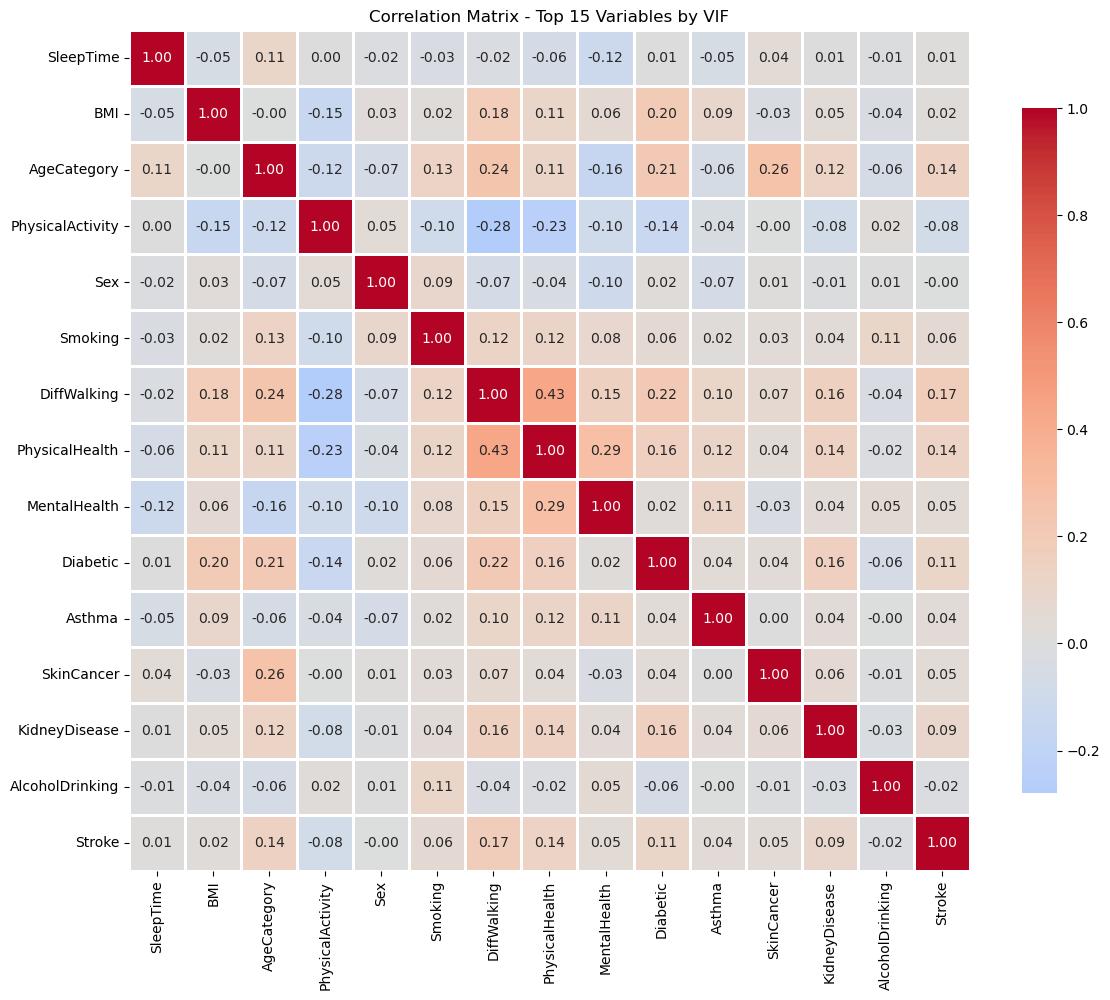


✓ Multicollinearity assessment complete


In [116]:
# Calculate VIF
print("\nVariance Inflation Factor (VIF) Analysis:")
print("Rule: VIF > 10 indicates high multicollinearity")
print("-"*60)

vif_data = pd.DataFrame()
vif_data["Variable"] = X_train.columns
vif_data["VIF"] = [variance_inflation_factor(X_train.values, i) for i in range(len(X_train.columns))]
vif_data = vif_data.sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

# Check for high VIF
high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f"\n⚠ Variables with VIF > 10: {len(high_vif)}")
    print(high_vif.to_string(index=False))
    print("\nAction: Consider removing highest VIF variables")
else:
    print("\n✓ No severe multicollinearity detected (all VIF < 10)")

# Correlation matrix for top variables
top_vif_vars = vif_data.head(15)['Variable'].tolist()
corr_matrix = X_train[top_vif_vars].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top 15 Variables by VIF')
plt.tight_layout()
plt.show()

print(f"\n✓ Multicollinearity assessment complete")

### Step 6: Training Data Evaluation

In [119]:
# Setup
master_data = pd.read_csv("master_data_recoded.csv")
master_data['Diabetic'] = master_data['Diabetic'].fillna(0)

with open('significant_variables.txt', 'r') as f:
    sig_vars = [line.strip() for line in f.readlines()]

X = master_data[sig_vars].fillna(0)
y = master_data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Fit model
X_train_sm = sm.add_constant(X_train)
model = sm.Logit(y_train, X_train_sm).fit(disp=0)

# Get predictions
y_train_prob = model.predict(X_train_sm)


print("\n---: ROC Curve and AUC (Training) ---")
fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)
roc_auc = auc(fpr, tpr)

print(f"AUC (Training): {roc_auc:.4f}")
print(f"Interpretation: {roc_auc:.1%} chance model ranks random positive > random negative")


---: ROC Curve and AUC (Training) ---
AUC (Training): 0.8291
Interpretation: 82.9% chance model ranks random positive > random negative


In [121]:
# Classification Table (default threshold = 0.5)
print("\n---: Classification Table (Threshold = 0.5) ---")
y_train_pred = (y_train_prob >= 0.5).astype(int)
cm = confusion_matrix(y_train, y_train_pred)

tn, fp, fn, tp = cm.ravel()
accuracy = (tp + tn) / (tp + tn + fp + fn)
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
f1 = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) > 0 else 0

print(f"\nConfusion Matrix:")
print(f"                Predicted")
print(f"              No      Yes")
print(f"Actual No   {tn:6d}  {fp:6d}")
print(f"       Yes  {fn:6d}  {tp:6d}")

print(f"\nMetrics:")
print(f"Accuracy:     {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Sensitivity:  {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"Specificity:  {specificity:.4f} ({specificity*100:.2f}%)")
print(f"Precision:    {precision:.4f}")
print(f"F1-Score:     {f1:.4f}")


---: Classification Table (Threshold = 0.5) ---

Confusion Matrix:
                Predicted
              No      Yes
Actual No   232059    1879
       Yes   19900    1998

Metrics:
Accuracy:     0.9149 (91.49%)
Sensitivity:  0.0912 (9.12%)
Specificity:  0.9920 (99.20%)
Precision:    0.5153
F1-Score:     0.1550


In [122]:
#  Optimal Threshold
print("\n--- Finding Optimal Threshold ---")

# Youden's Index: maximize (sensitivity + specificity - 1)
youden_index = tpr - fpr
optimal_idx = np.argmax(youden_index)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Threshold (Youden's Index): {optimal_threshold:.4f}")
print(f"At this threshold:")
print(f"  Sensitivity: {tpr[optimal_idx]:.4f}")
print(f"  Specificity: {1-fpr[optimal_idx]:.4f}")

# Apply optimal threshold
y_train_pred_opt = (y_train_prob >= optimal_threshold).astype(int)
cm_opt = confusion_matrix(y_train, y_train_pred_opt)
tn_opt, fp_opt, fn_opt, tp_opt = cm_opt.ravel()

sens_opt = tp_opt / (tp_opt + fn_opt)
spec_opt = tn_opt / (tn_opt + fp_opt)
acc_opt = (tp_opt + tn_opt) / (tp_opt + tn_opt + fp_opt + fn_opt)

print(f"\nOptimal Threshold Performance:")
print(f"Accuracy:     {acc_opt:.4f} ({acc_opt*100:.2f}%)")
print(f"Sensitivity:  {sens_opt:.4f} ({sens_opt*100:.2f}%)")
print(f"Specificity:  {spec_opt:.4f} ({spec_opt*100:.2f}%)")


--- Finding Optimal Threshold ---
Optimal Threshold (Youden's Index): 0.0782
At this threshold:
  Sensitivity: 0.8025
  Specificity: 0.7061

Optimal Threshold Performance:
Accuracy:     0.7144 (71.44%)
Sensitivity:  0.8025 (80.25%)
Specificity:  0.7061 (70.61%)


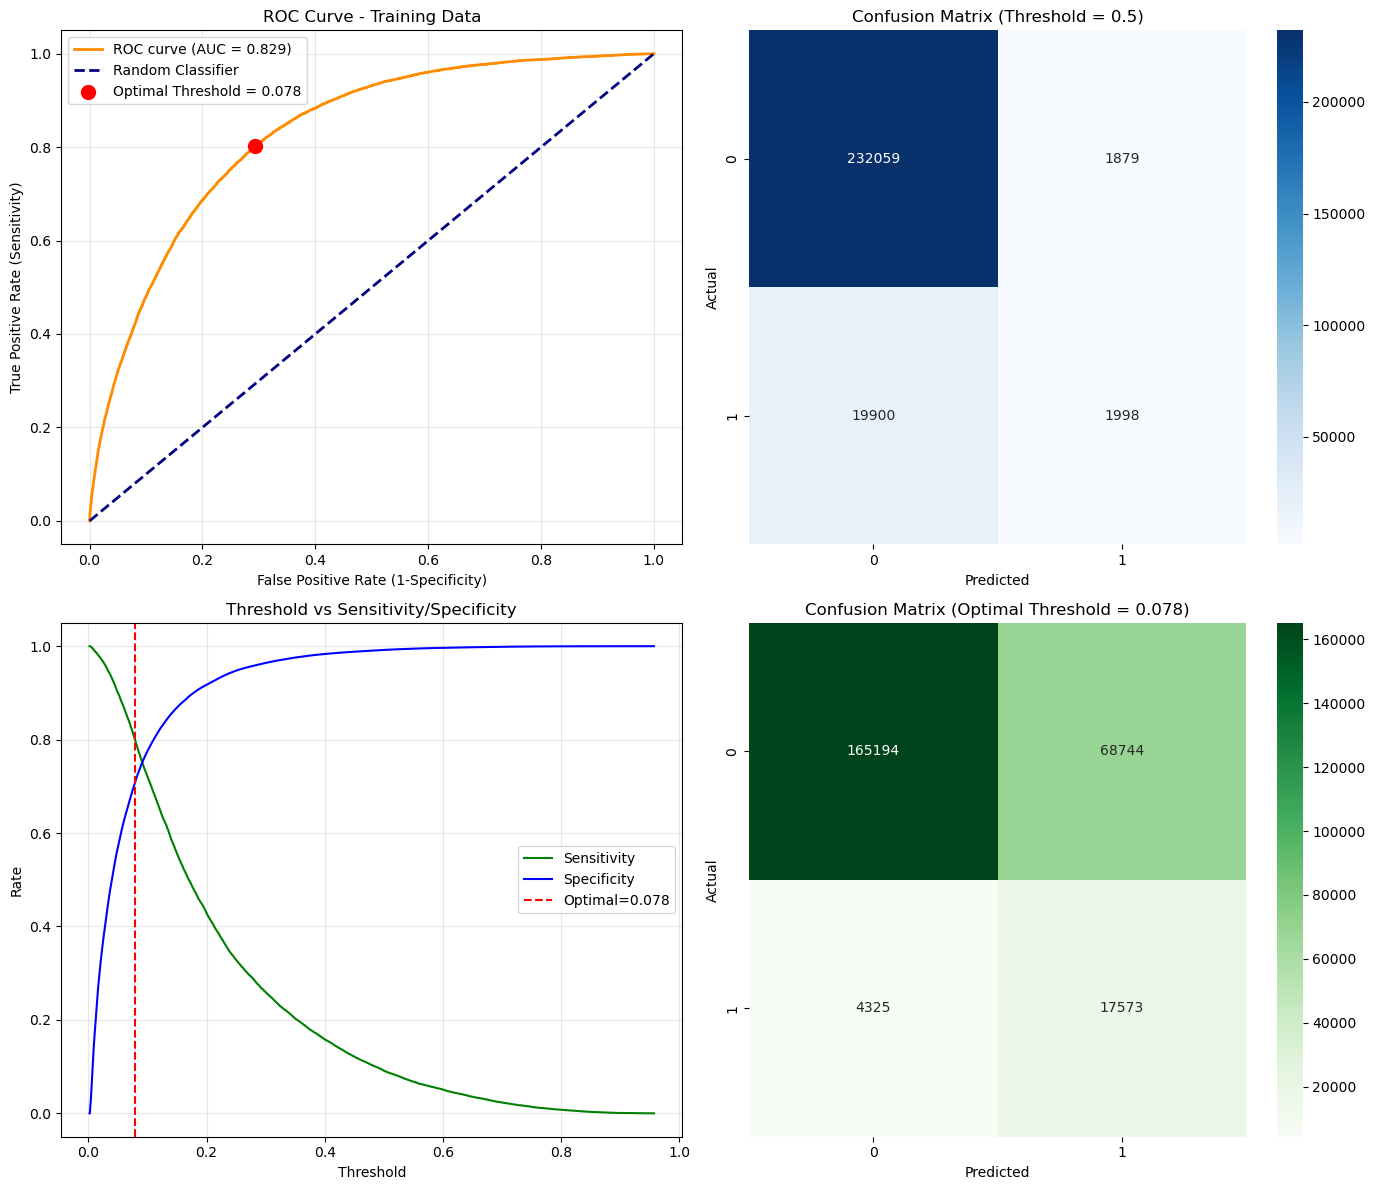

In [123]:
# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 12))

# ROC Curve
ax1.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax1.scatter(fpr[optimal_idx], tpr[optimal_idx], color='red', s=100, 
            label=f'Optimal Threshold = {optimal_threshold:.3f}', zorder=5)
ax1.set_xlabel('False Positive Rate (1-Specificity)')
ax1.set_ylabel('True Positive Rate (Sensitivity)')
ax1.set_title('ROC Curve - Training Data')
ax1.legend()
ax1.grid(alpha=0.3)

# Confusion Matrix Heatmap (default threshold)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2)
ax2.set_title('Confusion Matrix (Threshold = 0.5)')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

# Threshold vs Sensitivity/Specificity
ax3.plot(thresholds, tpr, label='Sensitivity', color='green')
ax3.plot(thresholds, 1-fpr, label='Specificity', color='blue')
ax3.axvline(optimal_threshold, color='red', linestyle='--', label=f'Optimal={optimal_threshold:.3f}')
ax3.set_xlabel('Threshold')
ax3.set_ylabel('Rate')
ax3.set_title('Threshold vs Sensitivity/Specificity')
ax3.legend()
ax3.grid(alpha=0.3)

# Confusion Matrix Heatmap (optimal threshold)
sns.heatmap(cm_opt, annot=True, fmt='d', cmap='Greens', ax=ax4)
ax4.set_title(f'Confusion Matrix (Optimal Threshold = {optimal_threshold:.3f})')
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [124]:
# Save results
from pathlib import Path

# Get project root
current_dir = Path.cwd()
if 'processed' in str(current_dir):
    project_root = current_dir.parent.parent
elif 'data' in str(current_dir):
    project_root = current_dir.parent
else:
    project_root = current_dir

results_summary = {
    'AUC_train': roc_auc,
    'Optimal_Threshold': optimal_threshold,
    'Accuracy_default': accuracy,
    'Sensitivity_default': sensitivity,
    'Specificity_default': specificity,
    'Accuracy_optimal': acc_opt,
    'Sensitivity_optimal': sens_opt,
    'Specificity_optimal': spec_opt
}

pd.DataFrame([results_summary]).to_csv(project_root / 'train_performance.csv', index=False)
print(f"\n✓ Training evaluation complete. Results saved to '{project_root / 'train_performance.csv'}'")


✓ Training evaluation complete. Results saved to 'C:\Users\willi\GitHub\Capstone_Project\train_performance.csv'
